# ResNet on CIFAR-10 — Code Walkthrough

This notebook implements, in PyTorch, the two architectures compared in He et al.'s *Deep Residual Learning for Image Recognition* (Section 4.2, CIFAR-10 experiment): a **plain convolutional network** and its **residual (ResNet)** counterpart, built from the exact same building blocks so that the only difference is the presence of identity shortcut connections.

The companion file `article.tex` contains the summary of the paper itself (problem, method, results). This notebook focuses on explaining the code: what each part does, and how it maps to the paper's equations.

---

## Mathematical Formulation & Architecture Design

The core hypothesis of ResNet is that fitting a residual mapping $\mathcal{F}(x)$ is easier than directly learning an unreferenced target mapping $\mathcal{H}(x)$.

$$\mathcal{F}(x) := \mathcal{H}(x) - x \implies \mathcal{H}(x) = \mathcal{F}(x) + x$$

### Building Block Breakdown

For a two-layer residual block, the mathematical transformation is given by:

$$y = \sigma\Big(\mathcal{F}(x, \{W_i\}) + x\Big)$$

where $\mathcal{F} = W_2 \, \sigma(W_1 x)$, $\sigma$ represents the **ReLU** activation function, and $x$ is the identity shortcut connection.

When feature map dimensions change (e.g., when subsampling via stride $2$), dimensions are matched using option (B) from the paper: a $1 \times 1$ convolution projection $W_s$:

$$y = \sigma\Big(\mathcal{F}(x, \{W_i\}) + W_s x\Big)$$



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device used:", device)
torch.manual_seed(42)

Device used: cuda


## 1. Data pipeline

`torchvision.datasets.CIFAR10` downloads and loads the dataset (50,000 train / 10,000 test images, $32\times32$ RGB, 10 classes).

Two transform pipelines are defined:
- **`transform_train`**: reproduces the paper's data augmentation — 4-pixel padding then a random $32\times32$ crop (`RandomCrop(32, padding=4)`), plus a random horizontal flip.
- **`transform_test`**: no augmentation, only normalization, so evaluation is deterministic.

Both pipelines normalize each channel using the CIFAR-10 per-channel mean/std (`MEAN`, `STD`), which centers and scales the input, helping the optimizer converge faster.

In [2]:
MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

BATCH_SIZE = 128
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=100, shuffle=False, num_workers=2)

print(f"Train: {len(train_set)} images | Test: {len(test_set)} images")

/home/gotrinx/Desktop/iaadl/iaadl/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 50000 images | Test: 10000 images


## 1.1 Explorer les données — exemples concrets

Avant l'entraînement, on peut vérifier ce que contient réellement le dataset.

L'objectif est de répondre à trois questions simples :
1. **Quelles sont les classes ?**
2. **À quoi ressemblent les images ?**
3. **Quelle est la forme des données envoyées au réseau ?**

Ces vérifications sont utiles pendant l'explication orale : elles montrent que le modèle reçoit des images RGB de `32×32` pixels et doit reconnaître **10 catégories**.


In [3]:
# Noms des 10 classes CIFAR-10
class_names = train_set.classes

print("Classes CIFAR-10 :")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

# Prendre un batch réel du DataLoader
images, labels = next(iter(train_loader))

print("\nInformations sur un batch :")
print("Images :", images.shape)   # [batch, channels, height, width]
print("Labels :", labels.shape)
print("Type   :", images.dtype)

print(f"\nExemple : image 0 -> classe {labels[0].item()} ({class_names[labels[0].item()]})")


Classes CIFAR-10 :
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck

Informations sur un batch :
Images : torch.Size([128, 3, 32, 32])
Labels : torch.Size([128])
Type   : torch.float32

Exemple : image 0 -> classe 6 (frog)


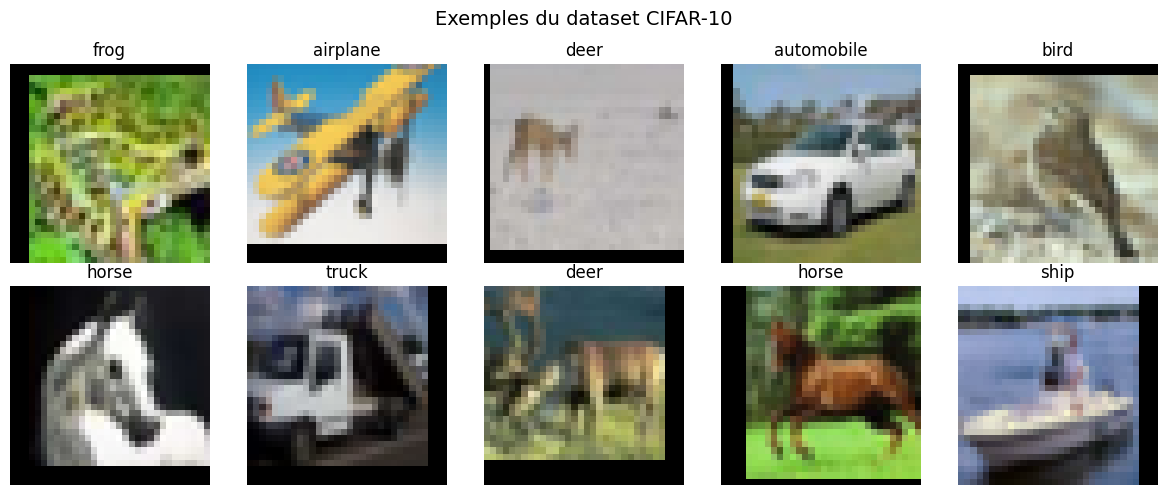

In [4]:
# Visualiser quelques images du dataset.
# Les images sont normalisées pour le réseau, donc on les "dé-normalise"
# uniquement pour les afficher correctement.

def denormalize(img):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (img.cpu() * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[labels[i].item()])
    ax.axis("off")

plt.suptitle("Exemples du dataset CIFAR-10", fontsize=14)
plt.tight_layout()
plt.show()


,Classe,Label,Nombre d'images
0,airplane,0,5000
1,automobile,1,5000
2,bird,2,5000
3,cat,3,5000
4,deer,4,5000
5,dog,5,5000
6,frog,6,5000
7,horse,7,5000
8,ship,8,5000
9,truck,9,5000


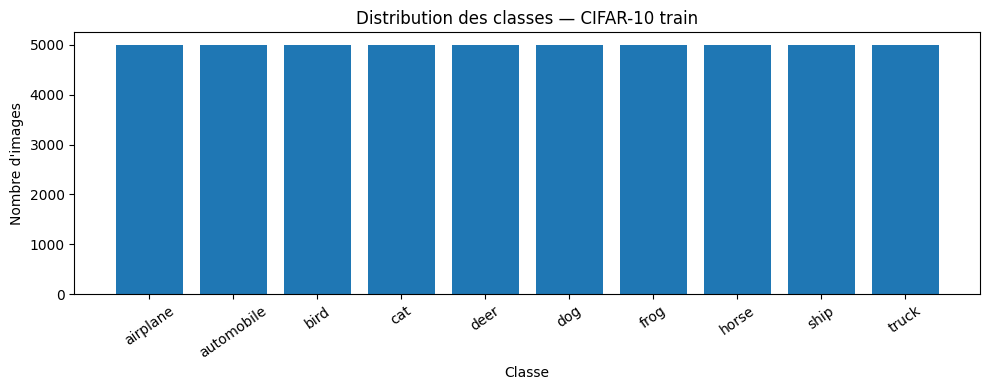

In [5]:
# Distribution des classes dans le dataset d'entraînement.
# Cela permet de vérifier que chaque classe possède environ le même nombre d'images.

train_targets = np.array(train_set.targets)
class_counts = np.bincount(train_targets, minlength=len(class_names))

class_table = {
    "Classe": class_names,
    "Label": list(range(len(class_names))),
    "Nombre d'images": class_counts.tolist(),
}

try:
    import pandas as pd
    display(pd.DataFrame(class_table))
except ImportError:
    for name, label, count in zip(class_names, range(10), class_counts):
        print(f"{label:>2} | {name:<12} | {count}")

plt.figure(figsize=(10, 4))
plt.bar(class_names, class_counts)
plt.title("Distribution des classes — CIFAR-10 train")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


## 2. The residual block (`BasicBlock`)

This class implements a single residual block: two $3\times3$ convolutions (each followed by Batch Normalization), with a shortcut path added to the output before the final ReLU.

**Key implementation details:**
- `self.use_shortcut` is a boolean flag: when `False`, the shortcut addition is skipped entirely, turning the block into a *plain* block. This lets `BasicBlock` serve both the plain network and the ResNet, guaranteeing they have an identical layer structure and parameter count — exactly the controlled comparison the paper relies on.
- When the shortcut needs to change dimensions (stride $\neq 1$ or channel count changes), two options are implemented:
  - **Option A** (`LambdaLayer`): spatially downsamples the input by simple striding (`x[:, :, ::stride, ::stride]`) and pads the channel dimension with zeros (`F.pad`) to match the new number of channels. This adds **no parameters**, matching the paper's default choice for CIFAR-10.
  - **Option B**: a $1\times1$ convolution + BatchNorm, i.e., a learned linear projection — available here for completeness, though not used in the CIFAR-10 experiments below.
- In `forward`, the addition `out + self.shortcut(x)` happens **before** the final `F.relu`, matching the paper's convention that the second nonlinearity is applied after the residual addition.

In [6]:
class LambdaLayer(nn.Module):
    def __init__(self, lambd):
        super().__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, use_shortcut=True, option="A"):
        super().__init__()
        self.use_shortcut = use_shortcut

        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if use_shortcut and (stride != 1 or in_planes != planes):
            if option == "A":
                pad = planes - in_planes
                self.shortcut = LambdaLayer(
                    lambda x: F.pad(x[:, :, ::stride, ::stride], (0, 0, 0, 0, 0, pad))
                )
            else:
                self.shortcut = nn.Sequential(
                    nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                    nn.BatchNorm2d(planes),
                )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_shortcut:
            out = out + self.shortcut(x)
        out = F.relu(out)
        return out

## 3. The full network (`ResNetCIFAR`)

This class assembles the $6n+2$ layer architecture described in the paper for CIFAR-10:

- One initial $3\times3$ convolution (16 filters) + BatchNorm + ReLU.
- Three stages (`layer1`, `layer2`, `layer3`) of $n$ residual blocks each, operating on feature maps of size $32\times32$, $16\times16$, and $8\times8$, with 16, 32, and 64 filters respectively. `_make_layer` builds each stage: the first block of `layer2` and `layer3` uses `stride=2` to halve the spatial resolution (this is also where the shortcut needs Option A/B, since both spatial size and channel count change); all other blocks use `stride=1`.
- A global average pooling (`AdaptiveAvgPool2d(1)`) that collapses each feature map to a single value per channel, followed by a single fully-connected layer to the 10 CIFAR-10 classes.
- `use_shortcut=False` instantiates the exact same structure **without** any shortcut connection — this is the *plain* network baseline used for comparison.

`_init_weights` applies He initialization to convolutional layers, matching the paper's stated initialization scheme (reference [13]), which is suited to ReLU activations.

In [7]:
class ResNetCIFAR(nn.Module):
    def __init__(self, n, num_classes=10, use_shortcut=True):
        super().__init__()
        self.in_planes = 16
        self.use_shortcut = use_shortcut

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        self.layer1 = self._make_layer(16, n, stride=1)
        self.layer2 = self._make_layer(32, n, stride=2)
        self.layer3 = self._make_layer(64, n, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, num_classes)

        self._init_weights()

    def _make_layer(self, planes, n_blocks, stride):
        strides = [stride] + [1] * (n_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, stride=s, use_shortcut=self.use_shortcut))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


N_BLOCKS = 3  # n=3 -> 6n+2 = 20 layers

resnet = ResNetCIFAR(n=N_BLOCKS, use_shortcut=True).to(device)
plainnet = ResNetCIFAR(n=N_BLOCKS, use_shortcut=False).to(device)

print(f"ResNet-{6*N_BLOCKS+2}  : {count_params(resnet):,} parameters")
print(f"Plain-{6*N_BLOCKS+2}   : {count_params(plainnet):,} parameters")
print("Both counts are identical: the shortcut connections add zero parameters (Option A).")

ResNet-20  : 269,722 parameters
Plain-20   : 269,722 parameters
Both counts are identical: the shortcut connections add zero parameters (Option A).


## 3.1 Lire l'architecture avec des données réelles

Cette cellule donne une vue synthétique du réseau : couche, type, taille de sortie et nombre de paramètres.

C'est pratique pour expliquer **ce qui se passe dans le réseau** sans devoir commenter chaque ligne de PyTorch.


In [8]:
# Afficher les dimensions qui traversent réellement le réseau.
# On utilise un seul batch pour observer les formes intermédiaires.

sample_x = images[:4].to(device)

with torch.no_grad():
    x = F.relu(resnet.bn1(resnet.conv1(sample_x)))
    print("Après conv1 :", tuple(x.shape))

    x = resnet.layer1(x)
    print("Après layer1:", tuple(x.shape))

    x = resnet.layer2(x)
    print("Après layer2:", tuple(x.shape))

    x = resnet.layer3(x)
    print("Après layer3:", tuple(x.shape))

    x = resnet.avgpool(x)
    print("Après global average pooling:", tuple(x.shape))

    x = torch.flatten(x, 1)
    print("Après flatten:", tuple(x.shape))

    x = resnet.fc(x)
    print("Sortie finale:", tuple(x.shape), "-> 10 classes")


Après conv1 : (4, 16, 32, 32)
Après layer1: (4, 16, 32, 32)
Après layer2: (4, 32, 16, 16)
Après layer3: (4, 64, 8, 8)
Après global average pooling: (4, 64, 1, 1)
Après flatten: (4, 64)
Sortie finale: (4, 10) -> 10 classes


In [9]:
# Tableau synthétique des principales étapes de ResNet-20.
architecture_table = [
    ["Entrée", "Image RGB", "3 × 32 × 32", "-"],
    ["Conv1", "3×3 convolution", "16 × 32 × 32", "3×3×3×16"],
    ["Layer 1", "3 BasicBlocks", "16 × 32 × 32", "Résidus"],
    ["Layer 2", "3 BasicBlocks, stride=2", "32 × 16 × 16", "Downsampling"],
    ["Layer 3", "3 BasicBlocks, stride=2", "64 × 8 × 8", "Downsampling"],
    ["Pooling", "Global Average Pooling", "64 × 1 × 1", "Réduction spatiale"],
    ["FC", "Linear", "10", "Classification"],
]

try:
    import pandas as pd
    display(pd.DataFrame(
        architecture_table,
        columns=["Étape", "Opération", "Taille de sortie", "Rôle"]
    ))
except ImportError:
    for row in architecture_table:
        print(row)


,Étape,Opération,Taille de sortie,Rôle
0,Entrée,Image RGB,3 × 32 × 32,-
1,Conv1,3×3 convolution,16 × 32 × 32,3×3×3×16
2,Layer 1,3 BasicBlocks,16 × 32 × 32,Résidus
3,Layer 2,"3 BasicBlocks, stride=2",32 × 16 × 16,Downsampling
4,Layer 3,"3 BasicBlocks, stride=2",64 × 8 × 8,Downsampling
5,Pooling,Global Average Pooling,64 × 1 × 1,Réduction spatiale
6,FC,Linear,10,Classification


In [10]:
# Comparaison directe : Plain-20 vs ResNet-20
comparison = [
    ["Plain-20", count_params(plainnet), "Non", "Baseline"],
    ["ResNet-20", count_params(resnet), "Oui", "Identity shortcuts"],
]

try:
    import pandas as pd
    display(pd.DataFrame(
        comparison,
        columns=["Modèle", "Paramètres entraînables", "Shortcut", "Rôle"]
    ))
except ImportError:
    for row in comparison:
        print(row)


,Modèle,Paramètres entraînables,Shortcut,Rôle
0,Plain-20,269722,Non,Baseline
1,ResNet-20,269722,Oui,Identity shortcuts


## 4. Training and evaluation functions

- **`train_model`**: standard PyTorch training loop. Uses `SGD` with `momentum=0.9` and `weight_decay=1e-4` (matching the paper), and a `MultiStepLR` scheduler that divides the learning rate by 10 at the epochs listed in `lr_milestones` (this implements the paper's "divide LR by 10 at fixed iteration counts" rule, converted to epochs for this smaller-scale run). At each epoch it records training loss, training error, and test error into a `history` dictionary, which is used for plotting below.
- **`evaluate`**: runs the model in `eval()` mode (disabling dropout/BN update behavior) over a data loader with no gradient tracking (`@torch.no_grad()`), and returns the classification error rate.

In [11]:
def train_model(model, train_loader, test_loader, epochs, lr_milestones, name="model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=lr_milestones, gamma=0.1)

    history = {"train_loss": [], "train_err": [], "test_err": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        t0 = time.time()

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        scheduler.step()
        train_loss = running_loss / total
        train_err = 100.0 * (1 - correct / total)
        test_err = evaluate(model, test_loader)

        history["train_loss"].append(train_loss)
        history["train_err"].append(train_err)
        history["test_err"].append(test_err)

        print(f"[{name}] Epoch {epoch+1:>3}/{epochs} | "
              f"loss={train_loss:.4f} | train_err={train_err:.2f}% | "
              f"test_err={test_err:.2f}% | {time.time()-t0:.1f}s")

    return history


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return 100.0 * (1 - correct / total)

## 5. Running the training

`EPOCHS_DEMO` / `LR_MILESTONES_DEMO` define a short schedule so this notebook runs quickly end-to-end. The full paper schedule (`EPOCHS_PAPER`, `LR_MILESTONES_PAPER`, in comments) can be swapped in for a longer run that more closely reproduces the paper's reported numbers — it requires a GPU to complete in reasonable time.

Both networks are trained with the exact same function, data, and hyperparameters — the only difference between the two runs is the `use_shortcut` flag set when each model was instantiated above.

In [12]:
# Full paper schedule (kept here for reference, not used by default):
# EPOCHS_PAPER = 91
# LR_MILESTONES_PAPER = [82, 123]

EPOCHS_DEMO = 5
LR_MILESTONES_DEMO = [3, 4]

print("Training the PLAIN network (baseline, no shortcuts)...")
history_plain = train_model(plainnet, train_loader, test_loader,
                             epochs=EPOCHS_DEMO, lr_milestones=LR_MILESTONES_DEMO, name="Plain-20")

print("\nTraining the ResNet (identity shortcuts)...")
history_resnet = train_model(resnet, train_loader, test_loader,
                              epochs=EPOCHS_DEMO, lr_milestones=LR_MILESTONES_DEMO, name="ResNet-20")

Training the PLAIN network (baseline, no shortcuts)...
[Plain-20] Epoch   1/5 | loss=1.7573 | train_err=66.24% | test_err=64.00% | 6.4s
[Plain-20] Epoch   2/5 | loss=1.2941 | train_err=47.01% | test_err=47.62% | 5.8s
[Plain-20] Epoch   3/5 | loss=1.0294 | train_err=36.67% | test_err=37.27% | 5.8s
[Plain-20] Epoch   4/5 | loss=0.7949 | train_err=28.12% | test_err=26.42% | 5.9s
[Plain-20] Epoch   5/5 | loss=0.7474 | train_err=26.42% | test_err=25.97% | 5.9s

Training the ResNet (identity shortcuts)...
[ResNet-20] Epoch   1/5 | loss=1.5918 | train_err=59.37% | test_err=50.90% | 6.4s
[ResNet-20] Epoch   2/5 | loss=1.0796 | train_err=38.87% | test_err=35.30% | 6.2s
[ResNet-20] Epoch   3/5 | loss=0.8778 | train_err=31.22% | test_err=32.39% | 5.9s
[ResNet-20] Epoch   4/5 | loss=0.6702 | train_err=23.56% | test_err=22.56% | 5.9s
[ResNet-20] Epoch   5/5 | loss=0.6283 | train_err=22.07% | test_err=22.13% | 5.9s


## 5.1 Tableau des résultats par époque

Les courbes sont utiles visuellement, mais un tableau permet aussi de lire précisément les valeurs.

- **train_loss** : erreur moyenne utilisée par l'optimiseur.
- **train_err** : pourcentage d'images mal classées sur l'entraînement.
- **test_err** : pourcentage d'images mal classées sur le test.

On peut ainsi expliquer l'évolution de l'apprentissage époque par époque.


In [13]:
def history_table(history, model_name):
    rows = []
    for epoch, (loss, train_err, test_err) in enumerate(
        zip(history["train_loss"], history["train_err"], history["test_err"]), 1
    ):
        rows.append([epoch, loss, train_err, test_err])

    try:
        import pandas as pd
        df = pd.DataFrame(
            rows,
            columns=["Époque", "Train loss", "Train error (%)", "Test error (%)"]
        )
        print(model_name)
        display(df.round(3))
        return df
    except ImportError:
        print(model_name)
        for row in rows:
            print(row)

df_plain = history_table(history_plain, "Plain-20")
df_resnet = history_table(history_resnet, "ResNet-20")


Plain-20


,Époque,Train loss,Train error (%),Test error (%)
0,1,1.757,66.238,64.00
1,2,1.294,47.014,47.62
2,3,1.029,36.668,37.27
3,4,0.795,28.116,26.42
4,5,0.747,26.420,25.97


ResNet-20


,Époque,Train loss,Train error (%),Test error (%)
0,1,1.592,59.368,50.90
1,2,1.080,38.866,35.30
2,3,0.878,31.224,32.39
3,4,0.670,23.558,22.56
4,5,0.628,22.066,22.13


In [14]:
# Résumé final sous forme de tableau.
summary_rows = [
    ["Plain-20", history_plain["train_err"][-1], history_plain["test_err"][-1]],
    ["ResNet-20", history_resnet["train_err"][-1], history_resnet["test_err"][-1]],
]

try:
    import pandas as pd
    summary_df = pd.DataFrame(
        summary_rows,
        columns=["Modèle", "Erreur train finale (%)", "Erreur test finale (%)"]
    )
    display(summary_df.round(2))
except ImportError:
    for row in summary_rows:
        print(row)


,Modèle,Erreur train finale (%),Erreur test finale (%)
0,Plain-20,26.42,25.97
1,ResNet-20,22.07,22.13


## 5.2 Exemples de prédictions

Une dernière vérification consiste à montrer quelques images du test et la classe prédite.

Cela permet de faire le lien entre :
**image → réseau → scores → classe prédite**.

Une prédiction est correcte lorsque la classe prédite correspond au label réel.


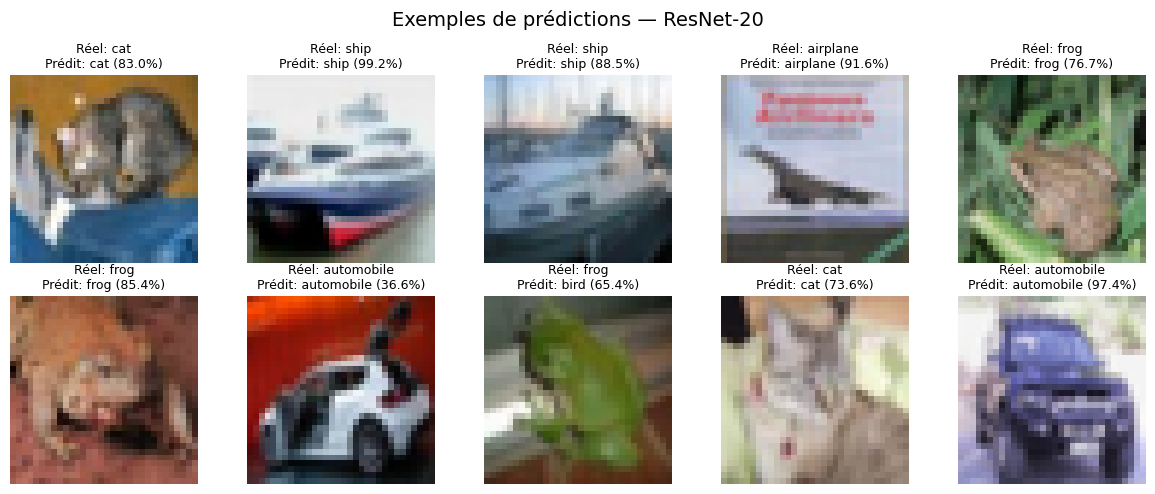

In [15]:
@torch.no_grad()
def show_predictions(model, loader, model_name, n=10):
    model.eval()
    batch_x, batch_y = next(iter(loader))
    batch_x = batch_x[:n].to(device)
    batch_y = batch_y[:n].to(device)

    logits = model(batch_x)
    probs = torch.softmax(logits, dim=1)
    preds = logits.argmax(dim=1)

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis("off")
            continue

        img = denormalize(batch_x[i]).permute(1, 2, 0).cpu().numpy()
        real = class_names[batch_y[i].item()]
        pred = class_names[preds[i].item()]
        confidence = probs[i, preds[i]].item() * 100

        ax.imshow(img)
        ax.set_title(
            f"Réel: {real}\nPrédit: {pred} ({confidence:.1f}%)",
            fontsize=9
        )
        ax.axis("off")

    plt.suptitle(f"Exemples de prédictions — {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

show_predictions(resnet, test_loader, "ResNet-20")


## 6. Plotting training curves

Simple side-by-side plots of training vs. test error over epochs for each model, saved to `plain_vs_resnet_comparison.png`.

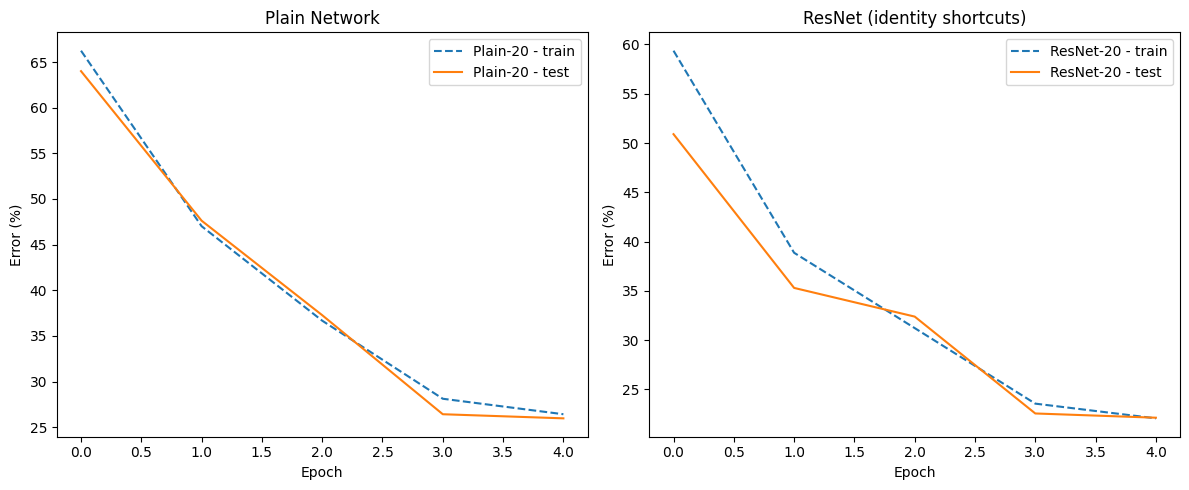


Final test error - Plain-20  : 25.97%
Final test error - ResNet-20 : 22.13%


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history_plain["train_err"], label="Plain-20 - train", linestyle="--")
axes[0].plot(history_plain["test_err"], label="Plain-20 - test")
axes[0].set_title("Plain Network")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Error (%)")
axes[0].legend()

axes[1].plot(history_resnet["train_err"], label="ResNet-20 - train", linestyle="--")
axes[1].plot(history_resnet["test_err"], label="ResNet-20 - test")
axes[1].set_title("ResNet (identity shortcuts)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Error (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("plain_vs_resnet_comparison.png", dpi=150)
plt.show()

print(f"\nFinal test error - Plain-20  : {history_plain['test_err'][-1]:.2f}%")
print(f"Final test error - ResNet-20 : {history_resnet['test_err'][-1]:.2f}%")

## 7. Notes on scaling this code up

- To reproduce Table 6 of the paper exactly, change `N_BLOCKS` to 3, 5, 7, 9, or 18 (yielding 20/32/44/56/110-layer networks) and use the full `EPOCHS_PAPER`/`LR_MILESTONES_PAPER` schedule.
- To switch the shortcut implementation from Option A to Option B, pass `option="B"` when constructing `BasicBlock` inside `_make_layer`.
- The `use_shortcut` flag is what makes this single codebase produce both networks compared in the notebook — no code duplication between the plain and residual variants.

## 8. Résumé pour l'explication orale

| Élément | Ce qu'il faut retenir |
|---|---|
| **CIFAR-10** | 50 000 images d'entraînement + 10 000 images de test, 10 classes, images RGB 32×32 |
| **Augmentation** | RandomCrop + RandomHorizontalFlip pour rendre le modèle plus robuste |
| **Normalisation** | Centre et met les canaux RGB à une échelle adaptée à l'apprentissage |
| **Plain Network** | Même architecture générale, mais sans connexion shortcut |
| **ResNet** | Ajoute une connexion identité : `F(x) + x` |
| **Downsampling** | Passage de 32×32 → 16×16 → 8×8 avec augmentation du nombre de canaux |
| **Global Average Pooling** | Transforme les cartes 8×8 en une valeur par canal |
| **FC finale** | Produit 10 scores, un par classe |
| **CrossEntropyLoss** | Compare les scores du modèle avec la vraie classe |
| **Erreur** | `error = 100 × (1 - accuracy)` |
| **But de la comparaison** | Observer l'effet des shortcuts en gardant le reste aussi identique que possible |
